#### House Price Prediction Analysis


In [1]:
# install required libraries
!pip install psycopg2-binary sqlalchemy pandas


In [2]:
#importing the necessary libraries
import pandas as pd
from sqlalchemy import create_engine
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
#connecting to PostgreSQl and read the table
# defining the connection parameters
db_user = "postgres"
db_password = "Shutterbug1,"
db_host = "localhost"
db_port = "5432"
db_name = "postgres"

# creating the SQLAlchemy engine
engine = create_engine(f"postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}")

# reading the table into a Dataframe
df = pd.read_sql("SELECT * FROM africa.property_data", engine)

# preview the Dataframe
df.head(20)

,BedRooms,Bath rooms,Size_sqft,location,year built,Garage Available,Furnishing,House Condition,Has_Pool,Lot Size,Price($)
0,3.0,1.0,1149,Rural,2004,NaN,Unfurnished,new,0.0,0.15,244043
1,NaN,2.0,1169,Rural,1989,1.0,,Old,0.0,0.23,211250
2,4.0,3.0,1409,Suburban,1993,1.0,Unfurnished,gd,0.0,0.19,257239
3,3.0,3.0,1647,Suburban,2021,0.0,,new,0.0,0.27,310316
4,2.0,3.0,1865,Urban,2009,0.0,furnised,old,1.0,0.39,334791
5,2.0,2.0,1179,ruraal,2020,NaN,Semi furnished,Old,0.0,0.32,228260
6,1.0,2.0,2097,Suburban,2004,0.0,Semi-Furnished,new,0.0,0.33,361672
7,5.0,3.0,1392,Suburban,1993,1.0,Semi furnished,new,0.0,0.12,259003
8,3.0,1.0,1491,Rural,2014,0.0,Furnished,old,0.0,0.01,263096
9,4.0,2.0,1201,ruraal,2013,0.0,Semi-Furnished,gd,0.0,0.13,242759


#### explanation of data importation
- pandas is used for data manipulation and analysis
- create_engine from SQLAlchemy helps create a connection to the PostgreSQL database
- the database credidentials and connection details were then input
- engine = create_engine(f"postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}")
-   this line creates a connection engine using SQLAlchemy
    postgresql+psycopg2 specifies the database dialect and driver
- to breakdown in simple terms how I created the SQLAlchemy engine:“Use the postgres user and password Shutterbug1, to connect to a PostgreSQL server on localhost at port 5432, and access the postgres database.”
- Colon (:): Commonly used to separate values in key:value format (e.g., user:pass or host:port).
- At symbol (@): Separates authentication details from host info, just like in email (anangwemike@gmail.com).
- Slash (/): Used to indicate hierarchy or location, like file paths or URLs (e.g., which database inside the server).
- df = pd.read_sql("SELECT * FROM africa.property_data", engine)
-   the SQL query fetches all records from the property_data table inside the africa schema
-   the result is stored in a pandas Dataframe "df" that allows me to analyse and manipulate the data

#### Cleaning the dataframe

In [4]:
# 2)understand the data structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0    BedRooms         954 non-null    float64
 1   Bath rooms        941 non-null    float64
 2   Size_sqft         1000 non-null   int64  
 3   location          1000 non-null   object 
 4   year built        1000 non-null   int64  
 5   Garage Available  896 non-null    float64
 6   Furnishing        1000 non-null   object 
 7   House Condition   1000 non-null   object 
 8   Has_Pool          945 non-null    float64
 9   Lot Size          1000 non-null   float64
 10  Price($)          1000 non-null   int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 86.1+ KB


#### Findings
- There are missing values in Bedrooms, Bathrooms, Garage Available, Furnishing and Has_Pool columns
- Some columns have inconsistent naming like; BedRooms, Bath rooms, year built

In [5]:
# 3)clean column names
print("Original column names:\n")# Print a message to label the output before displaying the original column names
print(df.columns)

Original column names:

Index([' BedRooms ', 'Bath rooms', 'Size_sqft', 'location', 'year built',
       'Garage Available', 'Furnishing', 'House Condition', 'Has_Pool',
       'Lot Size', 'Price($)'],
      dtype='object')


In [6]:
# clean column names
df.columns = df.columns.str.strip() # removes leading and trailing spaces
df.columns = df.columns.str.lower() # converts the column names to lowercase
df.columns = df.columns.str.replace(" ","_") # replaces spaces with underscores
df.columns = df.columns.str.replace(r"[^\w\s]", "", regex=True) # removes special characters

# preview cleaned columns
print("Cleaned column names:\n")# "\n" prints the label then moves to the next line before printing the column names 
print(df.columns)

Cleaned column names:

Index(['bedrooms', 'bath_rooms', 'size_sqft', 'location', 'year_built',
       'garage_available', 'furnishing', 'house_condition', 'has_pool',
       'lot_size', 'price'],
      dtype='object')


#### code explanation
- df.columns = df.columns.str.replace(r"[^\w\s]", "", regex=True)
- df.columns: Accesses the column names of the Dataframe "df".
- .str: Treats the column names as strings allowing me to apply string functions
- .replace(...): Replaces parts of the string; in this case column names, using the pattern provided
- r"[^\w\s]": A regular expression matching all characters except word characters and whitespace:
                \w matches the letters, numbers and underscores
                \s matches whitespace(spaces,tabs)
                ^ inside the brackets means"not"
                So this matches special characters like !@#$%^&* and removes them.
- "": This is the replacement string and since its empty it removes the matched characters
- regex=True: This confirms that the pattern is a regular expression

- The whole process of cleaning columns is important as it ensures column names are; clean, consistent and safe to use for modelling or plotting later.


In [7]:
# 4)check for missing values

# show the number of missing values in each column
print("Missing values in each column:\n")
print(df.isnull().sum())

Missing values in each column:

bedrooms             46
bath_rooms           59
size_sqft             0
location              0
year_built            0
garage_available    104
furnishing            0
house_condition       0
has_pool             55
lot_size              0
price                 0
dtype: int64


#### Code explanation
- print(df.isnull().sum())
- df.isnull(): Returns a Dataframe of the same shape with "True" where values are missing
- .sum(): adds up the "True" values giving a count of missing values per column

In [8]:
# 5)filling in the missing values

#bedrooms and bathrooms columns are numerical and filled in with median to reduce effect of outliers
df["bedrooms"]=df["bedrooms"].fillna(df["bedrooms"].median())
df["bath_rooms"]=df["bath_rooms"].fillna(df["bath_rooms"].median())

# garage_available,has_pool and furnishing filled with mode
df["garage_available"]=df["garage_available"].fillna(df["garage_available"].mode()[0])
df["furnishing"]=df["furnishing"].fillna(df["furnishing"].mode()[0])
df["has_pool"]=df["has_pool"].fillna(df["has_pool"].mode()[0])

#### Reasoning for methods chosen
- bedrooms and bath_rooms columns:median was used since it's a numerical column and skewness was being avoided by large outliers
- garage_available column: mode was used as it is a categorical column thus it's best to use the most frequent value
- furnishing column: mode was used as it is a categorical column thus the assumption of majority class is reasonable
- has_pool column: mode was used as its binary or categorical and using the most frequent is adequate

In [9]:
# confirm missing values after filling
print("Missing values after filling:\n")
print(df.isnull().sum())

Missing values after filling:

bedrooms            0
bath_rooms          0
size_sqft           0
location            0
year_built          0
garage_available    0
furnishing          0
house_condition     0
has_pool            0
lot_size            0
price               0
dtype: int64


In [10]:
# 6)standardizing columns
# view unique values in categorical columns

print("Unique values in 'location':", df['location'].unique()) #the .unique() function shows the distinct values in the location column
print("\nUnique values in 'furnishing':", df['furnishing'].unique())
print("\nUnique values in 'house_condition':", df['house_condition'].unique())


Unique values in 'location': ['Rural' 'Suburban' 'Urban' 'ruraal' 'sub-urban' 'urbn']

Unique values in 'furnishing': ['Unfurnished' '' 'furnised' 'Semi furnished' 'Semi-Furnished' 'Furnished']

Unique values in 'house_condition': ['new' 'Old' 'gd' 'old' 'New' 'Good']


In [11]:
# fix typos 
df["furnishing"].replace({"furnised": "Furnished","Semi furnished": "Semi-Furnished"}, inplace=True)
df["location"].replace({"ruraal": "Rural", "sub-urban": "Suburban", "urbn": "Urban"}, inplace=True)
df["house_condition"].replace({"new": "New", "gd":"Good", "old":"Old"}, inplace=True)
# .replace() function is used to replace typos with the new values in the column

C:\Users\USER\AppData\Local\Temp\ipykernel_6636\1364991840.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["furnishing"].replace({"furnised": "Furnished","Semi furnished": "Semi-Furnished"}, inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_6636\1364991840.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are s

In [12]:
# recheck after cleaning
print("Standardized 'furnishing' values:", df["furnishing"].unique())
print("\nStandardized 'location' values:", df["location"].unique())
print("\nStandardized 'house_condition' values:", df["house_condition"].unique())

Standardized 'furnishing' values: ['Unfurnished' '' 'Furnished' 'Semi-Furnished']

Standardized 'location' values: ['Rural' 'Suburban' 'Urban']

Standardized 'house_condition' values: ['New' 'Old' 'Good']


#### Feature Engineering and Modelling

In [13]:
# 1)derive "age_of_house" = current year - year built
current_year = datetime.now().year
df["age_of_house"] = current_year - df["year_built"]

In [14]:
# derive "price_per_sqft" = price efficiency per square foot
df["price_per_sqft"] = df["price"]/df["size_sqft"]

In [15]:
# rename has_pool column to has_pool_flag and garage_available to has_garage
df.rename(columns={
    "has_pool": "has_pool_flag",
    "garage_available": "has_garage"
}, inplace=True)

In [16]:
# preview the new dataframe
df[["year_built", "age_of_house", "size_sqft", "price", "price_per_sqft", "has_garage", "has_pool_flag"]].head(20)


,year_built,age_of_house,size_sqft,price,price_per_sqft,has_garage,has_pool_flag
0,2004,21,1149,244043,212.395997,1.0,0.0
1,1989,36,1169,211250,180.710009,1.0,0.0
2,1993,32,1409,257239,182.568488,1.0,0.0
3,2021,4,1647,310316,188.412872,0.0,0.0
4,2009,16,1865,334791,179.512601,0.0,1.0
5,2020,5,1179,228260,193.604750,1.0,0.0
6,2004,21,2097,361672,172.471149,0.0,0.0
7,1993,32,1392,259003,186.065374,1.0,0.0
8,2014,11,1491,263096,176.456070,0.0,0.0
9,2013,12,1201,242759,202.130724,0.0,0.0


#### Explanation for the columns
- age_of_house: older houses might be cheaper and in need of renovation.necessary for price modelling
- price_per_sqft: this column measures the pricing efficiency per area


In [17]:
# 2)converting categorical columns to numerical columns for ML
# check column data types
df.dtypes

bedrooms           float64
bath_rooms         float64
size_sqft            int64
location            object
year_built           int64
has_garage         float64
furnishing          object
house_condition     object
has_pool_flag      float64
lot_size           float64
price                int64
age_of_house         int64
price_per_sqft     float64
dtype: object

- location, furnishing and house_condition columns are categorical with house_condition being ordered and the rest unordered

In [18]:
# view unique values of categorical columns
print("Furnishing:", df["furnishing"].unique())
print("House Condition:", df["house_condition"].unique())
print("Location:", df["location"].unique())

Furnishing: ['Unfurnished' '' 'Furnished' 'Semi-Furnished']
House Condition: ['New' 'Old' 'Good']
Location: ['Rural' 'Suburban' 'Urban']


In [19]:
# encode categorical columns
# location column is one-hot encoded since it contains nominal variables(has no order)
df = pd.get_dummies(df, columns=["location"], drop_first=True)

#### Code explanation
- drop_first=True: avoids the dummy variable trap by dropping one category
- the code creates new binary columns for location_Rural 

In [20]:
# house_condition and furnishing columns contains ordinal variables 'old', 'good', 'new'
# label-encoding is used
# convert all text to lowercase and strip whitespace
df["house_condition"] = df["house_condition"].str.lower().str.strip() # this had already been done but maintaining for order 

#create an ordered mapping
condition_mapping = {
    "old": 1,
    "good": 2,
    "new": 3
}
#apply the mapping
df["house_condition_encoded"] = df["house_condition"].map(condition_mapping)

df["furnishing"] = df["furnishing"].str.lower().str.strip()

# create ordered mapping
furnishing_order = {
    "unfurnished": 1,
    "semi-furnished": 2,
    "furnished": 3
}
# apply the mapping
df["furnishing_encoded"] = df["furnishing"].map(furnishing_order)




In [21]:
# after label-encoding the new columns "house_condition_encoded" and "furnishing_encoded" had some missing values
# checking for unmatched values 
print("Unmatched house_condition values:")
print(df[df["house_condition_encoded"].isnull()]["house_condition"].unique())

print("\nUnmatched furnishing values:")
print(df[df["furnishing_encoded"].isnull()]["furnishing"].unique())


Unmatched house_condition values:
[]

Unmatched furnishing values:
['']


In [22]:
#cleaned text again
df["house_condition"] = df["house_condition"].str.lower().str.strip()
df["furnishing"] = df["furnishing"].str.lower().str.strip()


In [23]:
# readjust mapping after cleaning
condition_mapping = {
    "old": 1,
    "good": 2,
    "new": 3
}

furnishing_order = {
    "unfurnished": 1,
    "semi-furnished": 2,
    "furnished": 3
}


In [24]:
df["house_condition_encoded"] = df["house_condition"].map(condition_mapping)
df["furnishing_encoded"] = df["furnishing"].map(furnishing_order)


In [25]:
# checking for anymore missing values
print(df[["house_condition_encoded", "furnishing_encoded"]].isnull().sum())


house_condition_encoded      0
furnishing_encoded         157
dtype: int64


In [26]:
# replace the missing values found in "furnishing_encoded" column with 0
df["furnishing_encoded"] = df["furnishing_encoded"].fillna(0)


#### Code explanation
- label-encoding preserves the rank relationship between conditions helping the ML model learn better.used for columns whose contents have an order
- one-hot encoding is used for columns whose contents contain no order
- location column looks like it could be ordered but ordering based on population density or development isn't a quality ranking.
- for price urban areas may have higher prices but suburban areas may have better value per square foot thus the relationship is not linear. thus one-hot encoding is used to avoid introducing bias

- next the already cleaned and preprocessed dataframe is split into:
- a)training set used to build(train) the model
- b)the testing set used to evaluate how well the model performs on unseen data

In [27]:
# 3)dividing the Dataframe into training and testing sets for model development and evaluation
# dataframe has features(x) and a target column(y),in this case price
# define (x) features and (y) target
# Only keep numeric columns, including the encoded versions
x = df.drop(columns=["price", "house_condition", "furnishing"])  # Drop original string columns
y = df["price"] # target column

# split into training and testing sets (80% training and 20% test)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

#### Code explanation
- train_test_split: splits arrays or dataframes into random train and test subsets
- test_size=0.2: 20% of the data goes into the test set
- random_state=42: ensures reproducibility (the same split will be obtained every time)
- any number can be adopted fro the random_state provided its consistent. 42 is widely used as the default seed value as an inside joke as 42 is described as the answer to the ultimate question of life, the universe and everything(The Hitchhiker's guide to the galaxy:douglas adams)

#### Building a model
- linear regression is used as a starting point since its easy to implement, its interpretable and has a solid baseline for regression tasks


In [28]:
# 4)train a regression model to predict house prices
# initialize the model
model = LinearRegression()

# train the model on training data
model.fit(x_train, y_train)

# make predictions on test data
y_pred = model.predict(x_test)

# evaluate the model performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test,y_pred)

# print the results
print("Model Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Model Performance:
Mean Absolute Error (MAE): 5248.23
Mean Squared Error (MSE): 74548881.19
Root Mean Squared Error (RMSE): 8634.17
R^2 Score: 0.98


####  General Explanation
- MAE: Gives the average difference between actual and predicted prices and shows how much my predictions are off from actual price
- MSE: penalizes large errors more severely than MAE because the errors are squared.Helps in detecting models that have a few large errors
- RMSE: The standard deviation of prediction errors.Gives more weight to large errors but brings the unit back to the original scale.Gives a balance between penalizing large errors and keeping the results interpretable
- R^2 Score: Indicates how much variance in the price is explained by the model.(1 means perfect predictions,0 means the model is no better than guessing the mean,<0 means the model is worse than guessing the mean)

##### Interpretation of results
- MAE=5248.23: Shows that the model's prediction is off by 5248 currency units from the actual house prices.It's a low and acceptable error as it could just be about 1% of the value if you assume a house price of 500000.Thus the model shows excellent average prediction accuracy.
- MSE=74548881.19: It's the average of the squared errors and magnifies the impact of large errors.It shows that the large errors(outliers) are not drastically skewing the model
- RMSE=8634.17: brings the MSE back to the same unit as the price making it easier to interpret. This shows that my model's predictions are about 8634 currency units off with a higher penalty for large deviations.assuming a house price of 500000 this would represent 1.7% error which is within acceptable range and thus is good for regression
- R^2 Score=0.98: Tells me that 98% of the variation in house prices is explained by the model.This is an exceptionally strong model fit and only 2% of the price variability is left unexplained.This also tells me that the features(size,condition,location) effectively capture the determinants of house price
- From the results it can be concluded that the model is performing very well because:
- a)errors(MAE and MSE) are low and within acceptable range
- b)R^2 is very close to 1 which is ideal for regression
- c)there is very little unexplained variation in the target

##### Why a linear regression is used
- a)The goal is to predict house prices which are numerical and continuous and regression models are perfect for that.If the target was categorical then a classification model would be used instead
- b)House price is influenced by features like; location, square footage, number of bedrooms, furnishing e.t.c and all these features have a near linear relationship to price e.g a better location or more square footage equates to a higher price. Linear regression models these relationships efficiently
- c)Linear regression gives coefficients that show how much each feature affects the price and its also an easy interpretable formula.these features are useful with real estate where stakeholders want to understand why a model made a certain prediction
- d)It's a baseline model that can be used when performance is already strong and intrepretability matters.Thus switching to complex models like XGBoost or Random Forest is unnecessary


In [29]:
# Save the final cleaned dataset to a CSV file
df.to_csv("final_cleaned_house_data.csv", index=False)

print("Final cleaned dataset saved successfully.")


Final cleaned dataset saved successfully.


In [30]:
# Use raw string (prefix with r) to avoid escape issues in Windows path
df_cleaned = pd.read_csv(r"C:\Users\USER\python day 1\final_cleaned_house_data.csv")

# Preview the loaded data
df_cleaned.head(20)


,bedrooms,bath_rooms,size_sqft,year_built,has_garage,furnishing,house_condition,has_pool_flag,lot_size,price,age_of_house,price_per_sqft,location_Suburban,location_Urban,house_condition_encoded,furnishing_encoded
0,3.0,1.0,1149,2004,1.0,unfurnished,new,0.0,0.15,244043,21,212.395997,False,False,3,1.0
1,3.0,2.0,1169,1989,1.0,NaN,old,0.0,0.23,211250,36,180.710009,False,False,1,0.0
2,4.0,3.0,1409,1993,1.0,unfurnished,good,0.0,0.19,257239,32,182.568488,True,False,2,1.0
3,3.0,3.0,1647,2021,0.0,NaN,new,0.0,0.27,310316,4,188.412872,True,False,3,0.0
4,2.0,3.0,1865,2009,0.0,furnished,old,1.0,0.39,334791,16,179.512601,False,True,1,3.0
5,2.0,2.0,1179,2020,1.0,semi-furnished,old,0.0,0.32,228260,5,193.604750,False,False,1,2.0
6,1.0,2.0,2097,2004,0.0,semi-furnished,new,0.0,0.33,361672,21,172.471149,True,False,3,2.0
7,5.0,3.0,1392,1993,1.0,semi-furnished,new,0.0,0.12,259003,32,186.065374,True,False,3,2.0
8,3.0,1.0,1491,2014,0.0,furnished,old,0.0,0.01,263096,11,176.456070,False,False,1,3.0
9,4.0,2.0,1201,2013,0.0,semi-furnished,good,0.0,0.13,242759,12,202.130724,False,False,2,2.0


#### Visualization

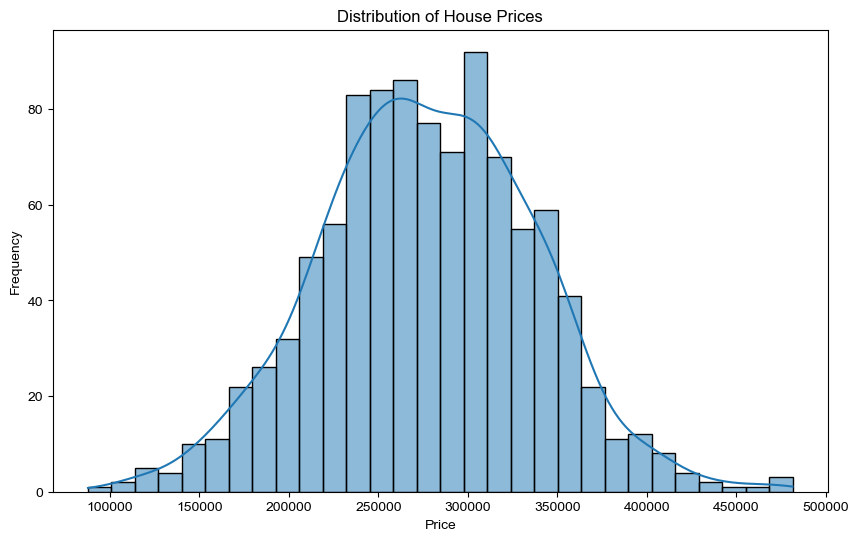

In [31]:
# import relevant libraries
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribution of House Prices
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned["price"], bins=30, kde=True)
sns.set(style="whitegrid")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


#### Key insights from the histogram
- Majority of the houses are priced between 200,000 and 325,000 and this range should be exploited more for pricing, marketing and investment focus.
- The KDE curve shows that the distribution is slightly right_skewed thus most houses are cheaper with a few expensive ones dragging the tail to the right. There's a concentration of demand in the mid-price segment,expensive properties seem to be rare and may require niche marketing.
- It's also notable that there are fewer low priced homes ranging from 100,000 to 175,000, thus stakeholders could consider subsidies or expansion in afordable housing to cater to this market.

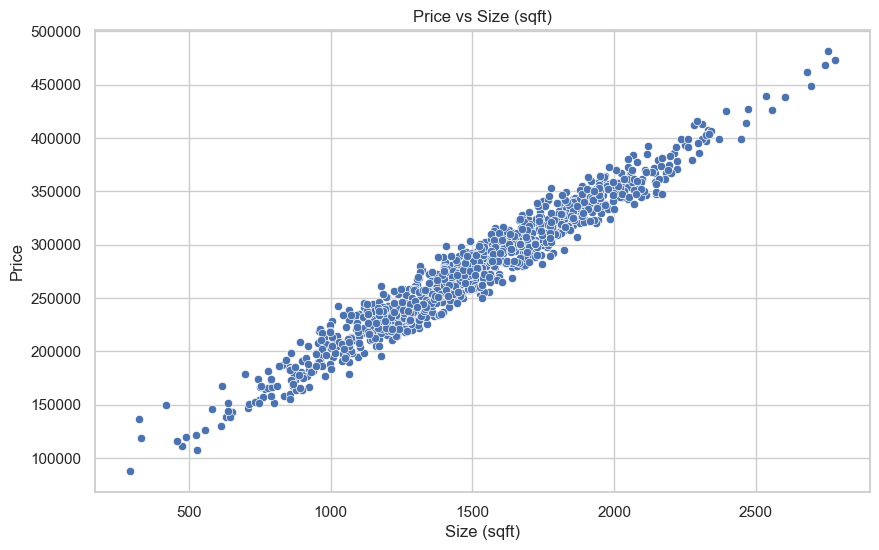

In [32]:
# 2. Price vs Size (Scatter plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(x="size_sqft", y="price", data=df_cleaned)
plt.title("Price vs Size (sqft)")
plt.xlabel("Size (sqft)")
plt.ylabel("Price")
plt.show()

#### Key insights from the scatter plot
- There's a clear upward trend showing an increase in house size leads to an increase in price,thus making size a major determinant of price. Buyers percieve more space as higher value thus a real estate firm can capitalize on this in marketing and pricing strategy
- There are a few outliers namely; a few properties under 1000 sqft appear more expensive than expected and some large houses above 2500 sqft have low prices.These outliers could represent investment opportunities like cheap large homes or anomalies that require futher investigation like mispricing of large houses.
- Prices keep increasing steadily with price. Thus tiered pricing based on size is appropriate and predictable for this market.

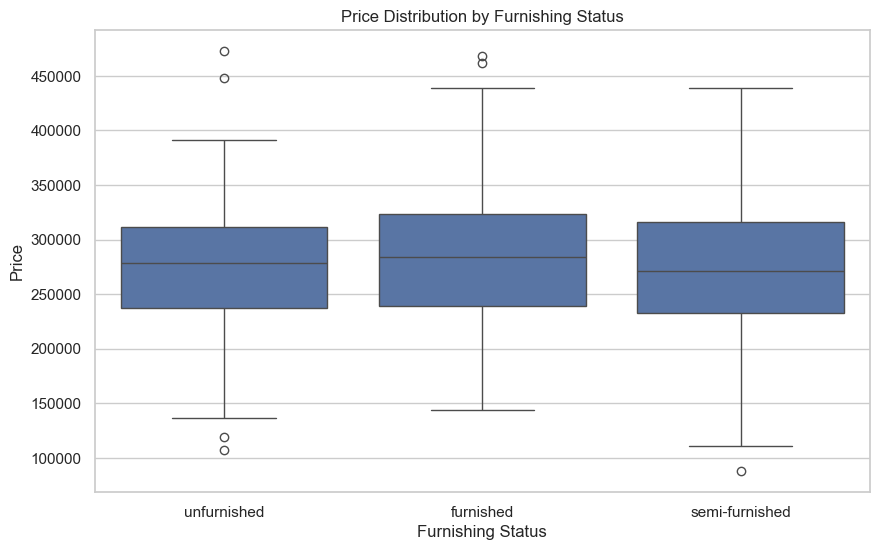

In [33]:
# 3. Boxplot of Price by Furnishing Status
plt.figure(figsize=(10, 6))
sns.boxplot(x="furnishing", y="price", data=df_cleaned)
plt.title("Price Distribution by Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Price")
plt.show()

#### Key insights from the boxplot
- The median price is slightly higher for furnished houses, followed by semi-furnished then unfurnished but the differences are not very large. Furnishing adds value but doesn't drastically change the median price,thus furnishing might not be very key in price determination.
- All three categories show a similar interquartile range so price variability is not highly affected by furnishing levels.This shows that predictability of returns is stable across furnishing levels.
- Each furnishing type has outliers with some unfurnished houses priced very low and some furnished houses priced quite high. Thus the high priced furnished homes could represent luxury market opportunities while low priced unfurnished homes could be renovation targets